In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
df.shape

(541909, 8)

In [3]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
# Statistical summary
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.shape

(541909, 8)

In [8]:
df = df.dropna(subset=['CustomerID'])

In [9]:
df.shape

(406829, 8)

In [10]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [11]:
df.shape

(406829, 8)

In [12]:

df = df.drop_duplicates()
df.shape

(401604, 8)

In [13]:
'''
STEP 5 — Handle Cancelled Orders
Important

Agar InvoiceNo me C hai → order cancelled hai
'''
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]
df.shape

(392732, 8)

In [14]:
df = df[df['Quantity'] > 0]

In [15]:
# convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


In [17]:
#STEP 8 — Create Revenue Column imp--
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [19]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [21]:
# STEP 9 — Feature Engineering   , Create Month Column
df['Month'] = df['InvoiceDate'].dt.month

In [22]:
#Create Year Column
df['Year'] = df['InvoiceDate'].dt.year

In [23]:
#Create Day Column
df['Day'] = df['InvoiceDate'].dt.day_name()

In [24]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Year,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,2010,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,2010,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,Wednesday


In [25]:
#STEP 10 — Exploratory Data Analysis (EDA)
#1. Total Revenue
total_revenue = df['Revenue'].sum()

print(total_revenue)

8887208.894


In [26]:
#2. Top 10 Products
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

In [27]:
#3. Top Countries
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

top_countries

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [28]:
#4. Monthly Sales
monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales

Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: Revenue, dtype: float64

In [29]:
#5. Top Customers
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [30]:
# STEP 11 — Data Visualization
#Import Libraries
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


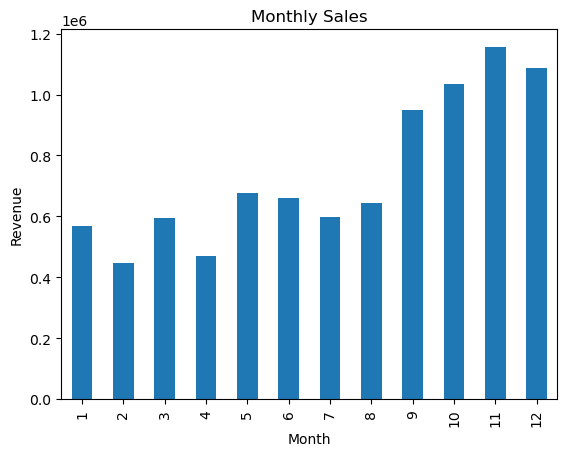

In [31]:
#1. Monthly Sales Chart
monthly_sales.plot(kind='bar')

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

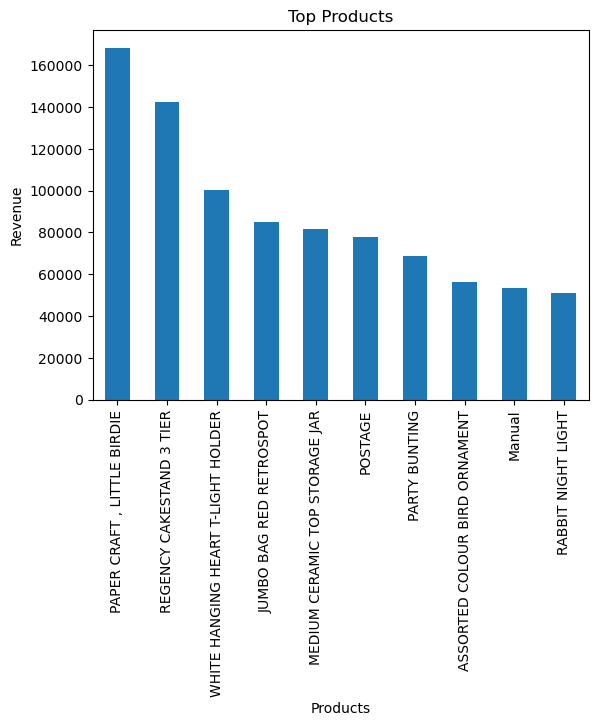

In [32]:
#2. Top Products Chart
top_products.plot(kind='bar')

plt.title("Top Products")
plt.xlabel("Products")
plt.ylabel("Revenue")

plt.show()

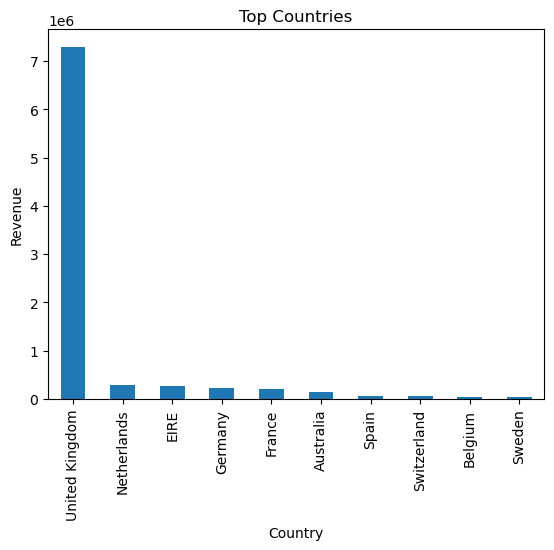

In [33]:
#3. Country-wise Sales
top_countries.plot(kind='bar')

plt.title("Top Countries")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

In [35]:
#STEP 12 — Advanced Analysis (IMPORTANT FOR RESUME)
#Repeat Customers
repeat_customers = df['CustomerID'].value_counts()

repeat_customers

CustomerID
17841.0    7676
14911.0    5672
14096.0    5111
12748.0    4413
14606.0    2677
           ... 
17747.0       1
16737.0       1
18184.0       1
15313.0       1
13106.0       1
Name: count, Length: 4339, dtype: int64

In [36]:
#Average Order Value
avg_order_value = df.groupby('InvoiceNo')['Revenue'].sum().mean()

print(avg_order_value)

479.45667317652135


In [37]:
#Best Selling Day
best_day = df.groupby('Day')['Revenue'].sum().sort_values(ascending=False)

best_day

Day
Thursday     1973015.730
Tuesday      1697733.801
Wednesday    1584283.830
Friday       1483080.811
Monday       1363604.401
Sunday        785490.321
Name: Revenue, dtype: float64

In [ ]:
'''
BUSINESS INSIGHTS

United Kingdom generated highest revenue.
November had highest sales.
Few customers contributed major revenue.
Certain products dominate total sales.
Weekend sales are higher.
'''

In [38]:
#STEP 14 — Export Cleaned Data
df.to_csv("cleaned_ecommerce_data.csv", index=False)